<a href="https://colab.research.google.com/github/Madhulatha-2006/-Handwritten-Character-Recognition-ml/blob/main/handwritten_char_recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,610 (951.60 KB)

 Trainable params: 243,610 (951.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 108s 76ms/step - accuracy: 0.7294 - loss: 0.8950 - val_accuracy: 0.8997 - val_loss: 0.2913
Epoch 2/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 91s 66ms/step - accuracy: 0.9177 - loss: 0.2439 - val_accuracy: 0.9158 - val_loss: 0.2410
Epoch 3/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9321 - loss: 0.1959 - val_accuracy: 0.9229 - val_loss: 0.2261
Epoch 4/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9401 - loss: 0.1669 - val_accuracy: 0.9213 - val_loss: 0.2337
Epoch 5/5
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 142s 66ms/step - accuracy: 0.9472 - loss: 0.1421 - val_accuracy: 0.9222 - val_loss: 0.2255
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9222 - loss: 0.2300
Test Accuracy: 0.9221621751785278
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Predicted: M


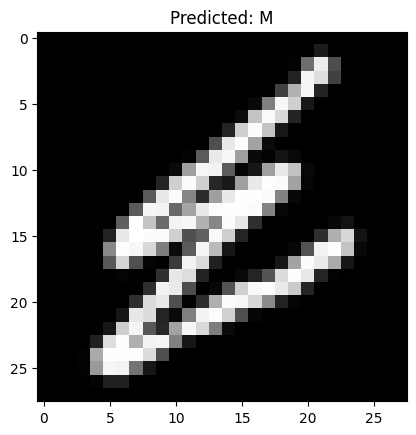

In [ ]:
# -----------------------------------------------------------
# Handwritten Character Recognition using EMNIST (CNN Model)
# -----------------------------------------------------------

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 1. LOAD EMNIST DATASET
# -----------------------------------------------------------
# EMNIST dataset is available in tensorflow-datasets
!pip install tensorflow-datasets

import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# -----------------------------------------------------------
# 2. PREPROCESS DATA
# -----------------------------------------------------------
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    # EMNIST labels start from 1 → convert to 0-25
    label = label - 1
    return image, label

batch_size = 64

ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache().shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# -----------------------------------------------------------
# 3. BUILD CNN MODEL
# -----------------------------------------------------------
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(26, activation='softmax')   # A-Z → 26 classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# -----------------------------------------------------------
# 4. TRAIN MODEL
# -----------------------------------------------------------
history = model.fit(
    ds_train,
    epochs=5,
    validation_data=ds_test
)

# -----------------------------------------------------------
# 5. EVALUATE MODEL
# -----------------------------------------------------------
test_loss, test_acc = model.evaluate(ds_test)
print("Test Accuracy:", test_acc)

# -----------------------------------------------------------
# 6. PREDICT SAMPLE
# -----------------------------------------------------------
for images, labels in ds_test.take(1):
    sample_img = images[0]
    sample_label = labels[0]

    pred = model.predict(sample_img[None, ...])
    print("Predicted:", chr(np.argmax(pred)+65))  # Convert index to A-Z

    plt.imshow(sample_img.numpy().reshape(28,28), cmap='gray')
    plt.title("Predicted: " + chr(np.argmax(pred)+65))
    plt.show()
